# Two-Dimensional `Transmitter`

In [1]:
import math
from collections.abc import Callable

import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from jacinta.processor.evaluator import ZScoreEvaluator
from jacinta.processor.transmitter import Transmitter
from jacinta.utils.scheduler import ConstantScheduler

## Configuration

In [2]:
MIN_X, MAX_X = -10.0, 10.0
MIN_Y, MAX_Y = -10.0, 10.0
MIN_Z, MAX_Z = -1.0, 1.0

# hyperparameters
MEAN_EMA_RATE = 0.001
VAR_EMA_RATE = 0.001
BIAS_SCALE = 10.0
LEARNING_RATE = 0.001
HITS_RATE = 1000
MIN_WIDTH = 1
MAX_DEPTH = None
SEED = 42

# simulation parameters
N_STEPS = 10000
N_PLOTS = 5

## Visualization Utilities

In [3]:
def eval_function(
    function: Callable[[float, float], float], x: float, y: float
) -> float:
    """
    Safely evaluate a function for the given values.

    Args:
        function (Callable[[float, float], float]): The function to evaluate.
        x (float): The first value to evaluate the function at.
        y (float): The second value to evaluate the function at.

    Returns:
        float: The result of the function evaluation.
    """
    try:
        z = function(x, y)
        if not math.isfinite(z):
            z = math.nan
        z = max(min(z, MAX_Z), MIN_Z)
    except (ArithmeticError, ValueError):
        z = math.nan
    return z

In [4]:
def plot_function(
    ax: plt.Axes,
    function: Callable[[float, float], float],
    n_points: int = 100,
    elev: float = 30.0,
    azim: float = 30.0,
) -> None:
    """
    Plot a function.

    Args:
        ax (plt.Axes): The axes to plot on.
        function (Callable[[float, float], float]): The function to plot.
        n_points (int): The number of points to plot per dimension.
            Defaults to 100.
        elev (float): The elevation of the viewing angle.
            Defaults to 30.0.
        azim (float): The azimuth of the viewing angle.
            Defaults to 30.0.
    """
    # evaluate the function
    x_step = (MAX_X - MIN_X) / (n_points - 1)
    y_step = (MAX_Y - MIN_Y) / (n_points - 1)
    x_vals = [MIN_X + idx * x_step for idx in range(n_points)]
    y_vals = [MIN_Y + idx * y_step for idx in range(n_points)]
    x_grid = [x_val for y_val in y_vals for x_val in x_vals]
    y_grid = [y_val for y_val in y_vals for x_val in x_vals]
    z_grid = [
        eval_function(function, x_val, y_val) for y_val in y_vals for x_val in x_vals
    ]
    # build the mesh triangles
    triangles = []
    for row in range(n_points - 1):
        for col in range(n_points - 1):
            # build the mesh cell
            top_left = row * n_points + col
            top_right = top_left + 1
            bottom_left = (row + 1) * n_points + col
            bottom_right = bottom_left + 1
            # split the cell into two triangles
            triangles.append([top_left, top_right, bottom_right])
            triangles.append([top_left, bottom_right, bottom_left])
    # plot the function
    ax.plot_trisurf(
        x_grid,
        y_grid,
        z_grid,
        triangles=triangles,
        cmap="viridis",
        antialiased=False,
    )
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim(MIN_X, MAX_X)
    ax.set_ylim(MIN_Y, MAX_Y)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel("f(x, y)", rotation=90)
    ax.set_title(f"Reward Function (elev={elev}, azim={azim})")
    ax.grid(visible=True)
    return

In [5]:
def get_leaves(
    transmitter: Transmitter, probability: float = 1.0, bias: float = 0.0
) -> list[tuple[Transmitter, float]]:
    """
    Get the transmitter leaves with their probability densities.

    Args:
        transmitter (Transmitter): The transmitter to get the leaves of.
        probability (float): The probability of the transmitter being selected.
            Defaults to 1.0.
        bias (float): The bias to apply to the log-weights.
            Defaults to 0.0.

    Returns:
        list[tuple[Transmitter, float]]: A list of tuples containing the transmitter
            leaves and their probability densities.
    """
    # check if the transmitter is a leaf
    if transmitter.is_leaf:
        x_lower, x_upper = transmitter.bounds[0]
        y_lower, y_upper = transmitter.bounds[1]
        # compute the probability density of the leaf
        probability_density = probability / ((x_upper - x_lower) * (y_upper - y_lower))
        leaves = [(transmitter, probability_density)]
    # otherwise, recursively get its leaves
    else:
        log_weights = [child.log_weight for child in transmitter.children]
        # bias the log-weights
        bias_scale = 1.0 + bias * transmitter.bias_scale_scheduler(transmitter.depth)
        log_weights = [log_weight * bias_scale for log_weight in log_weights]
        # stable log-weights with softmax
        max_log_weight = max(log_weights)
        weights = [math.exp(log_weight - max_log_weight) for log_weight in log_weights]
        # get the transmitter leaves
        leaves = []
        total_weight = sum(weights)
        for child, weight in zip(transmitter.children, weights, strict=True):
            # compute the probability of the child being selected
            child_probability = probability * weight / total_weight
            child_leaves = get_leaves(child, child_probability, bias)
            leaves.extend(child_leaves)
    return leaves

In [6]:
def plot_transmitter(
    ax: plt.Axes,
    transmitter: Transmitter,
    bias: float = 0.0,
    elev: float = 30.0,
    azim: float = 30.0,
) -> None:
    """
    Plot the probability density function of a transmitter.

    Args:
        ax (plt.Axes): The axes to plot on.
        transmitter (Transmitter): The transmitter to plot.
        bias (float): The bias to apply to the log-weights.
            Defaults to 0.0.
        elev (float): The elevation of the viewing angle.
            Defaults to 30.0.
        azim (float): The azimuth of the viewing angle.
            Defaults to 30.0.
    """
    # get the transmitter leaves
    leaves = get_leaves(transmitter, bias=bias)
    # sort the leaves by their lower bounds
    leaves.sort(key=lambda leaf: (leaf[0].bounds[0][0], leaf[0].bounds[1][0]))
    # get the probability density of each leaf
    probability_densities = [probability_density for _, probability_density in leaves]
    # normalize the probability densities for the color map
    max_density = max(probability_densities)
    if max_density == 0.0:
        max_density = 1.0
    normalize = Normalize(vmin=0.0, vmax=max_density)
    # set the height of the color bar
    z_max = max_density * 1.05
    colorbar_height = max_density / z_max
    colorbar_ax = ax.inset_axes(
        [1.02, 0.0, 0.04, colorbar_height],
        transform=ax.transAxes,
    )
    # plot the color bar
    colormap = colormaps["RdYlGn"]
    scalar_mappable = ScalarMappable(norm=normalize, cmap=colormap)
    scalar_mappable.set_array([])
    colorbar = ax.figure.colorbar(scalar_mappable, cax=colorbar_ax)
    colorbar.solids.set_alpha(0.8)
    # color each rectangle according to its probability density
    for leaf, probability_density in leaves:
        x_lower, x_upper = leaf.bounds[0]
        y_lower, y_upper = leaf.bounds[1]
        color = colormap(normalize(probability_density))
        ax.bar3d(
            x_lower,
            y_lower,
            0.0,
            x_upper - x_lower,
            y_upper - y_lower,
            probability_density,
            color=color,
            alpha=0.8,
        )
    # plot the transmitter
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim(MIN_X, MAX_X)
    ax.set_ylim(MIN_Y, MAX_Y)
    ax.set_zlim(0.0, z_max)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel("Probability Density", rotation=90)
    ax.set_title(
        "Transmitter Probability Density Function "
        f"(bias={bias}, elev={elev}, azim={azim})"
    )
    ax.grid(visible=True)
    return

## Reward Function

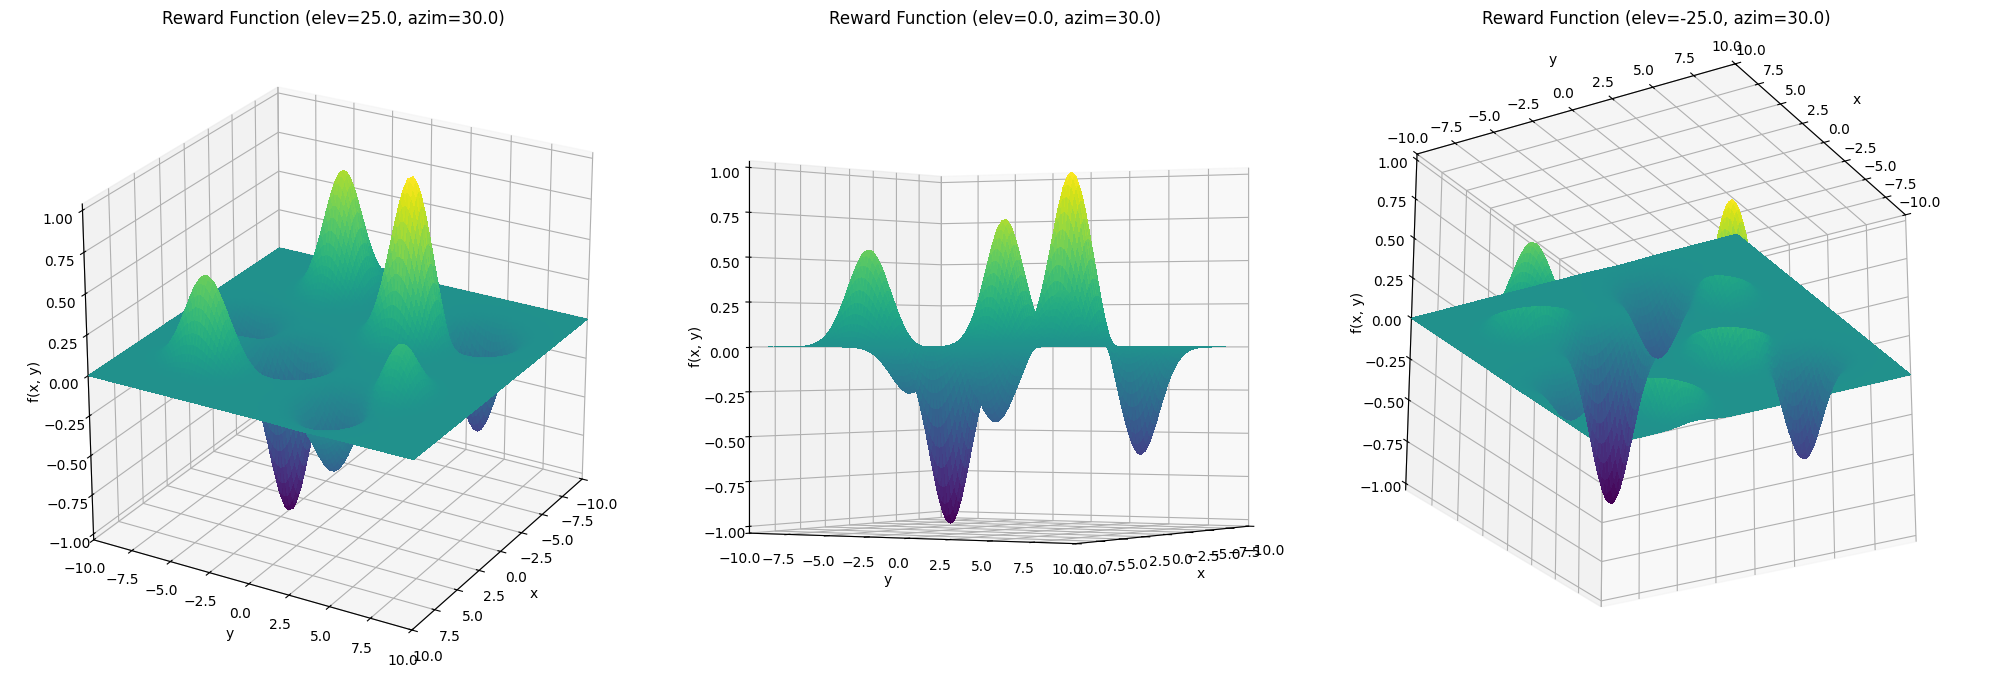

In [7]:
def reward_function(x: float, y: float) -> float:
    """
    Reward function.

    Args:
        x (float): The first value to evaluate the function at.
        y (float): The second value to evaluate the function at.

    Returns:
        float: The result of the function evaluation.
    """
    z = (
        0.9988 * math.exp(-(((x + 2.8) / 1.7) ** 2 + ((y - 2.7) / 1.5) ** 2))
        + 0.7550 * math.exp(-(((x + 6.7) / 1.8) ** 2 + ((y + 3.8) / 1.4) ** 2))
        + 0.5450 * math.exp(-(((x - 5.6) / 1.3) ** 2 + ((y + 5.2) / 1.7) ** 2))
        + 0.3150 * math.exp(-(((x - 3.8) / 1.5) ** 2 + ((y - 5.8) / 1.2) ** 2))
        - 0.9993 * math.exp(-(((x - 2.2) / 1.5) ** 2 + ((y + 2.1) / 1.6) ** 2))
        - 0.6200 * math.exp(-(((x + 5.2) / 1.4) ** 2 + ((y - 5.7) / 1.5) ** 2))
        - 0.4100 * math.exp(-(((x - 6.4) / 1.7) ** 2 + ((y - 3.2) / 1.4) ** 2))
        - 0.2700 * math.exp(-(((x + 0.8) / 1.3) ** 2 + ((y + 6.5) / 1.6) ** 2))
    )
    return z


# plot the reward function
fig, ax = plt.subplots(ncols=3, figsize=(20, 7), subplot_kw={"projection": "3d"})
plot_function(ax[0], reward_function, elev=25.0)
plot_function(ax[1], reward_function, elev=0.0)
plot_function(ax[2], reward_function, elev=-25.0)
# adjust the aspect ratio of each plot
for axis in ax:
    axis.set_box_aspect((1, 1, 1), zoom=0.95)
fig.tight_layout()
plt.show()

## Simulation

In [8]:
# initialize a 2D Transmitter
transmitter = Transmitter(
    bounds=((MIN_X, MAX_X), (MIN_Y, MAX_Y)),
    evaluator=ZScoreEvaluator(MEAN_EMA_RATE, VAR_EMA_RATE),
    bias_scale_scheduler=ConstantScheduler(value=BIAS_SCALE),
    learning_rate_scheduler=ConstantScheduler(value=LEARNING_RATE),
    hits_rate_scheduler=ConstantScheduler(value=HITS_RATE),
    min_width=MIN_WIDTH,
    max_depth=MAX_DEPTH,
    seed=SEED,
)

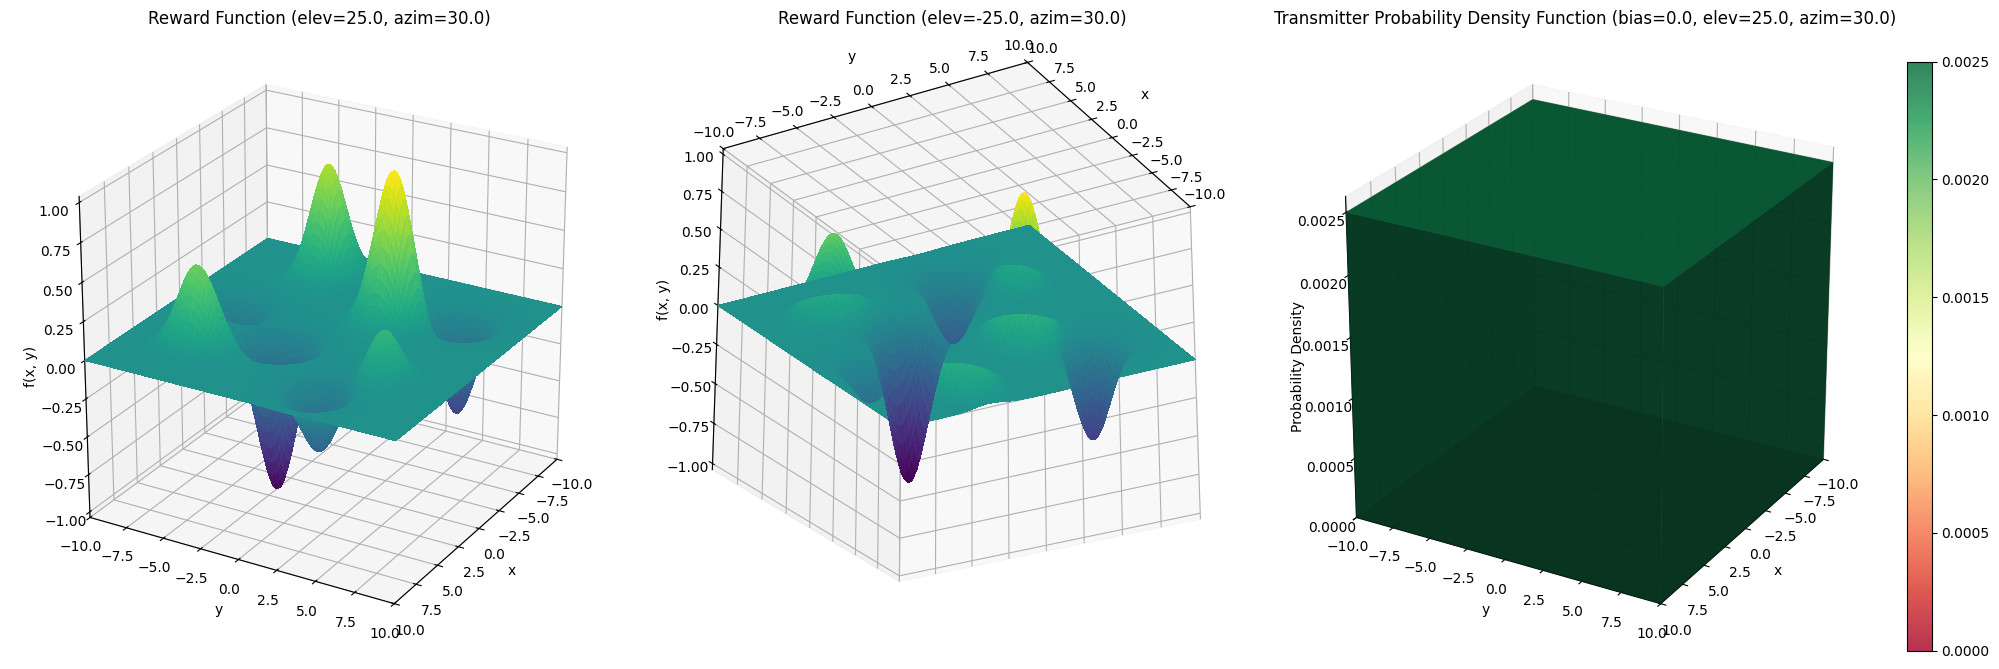

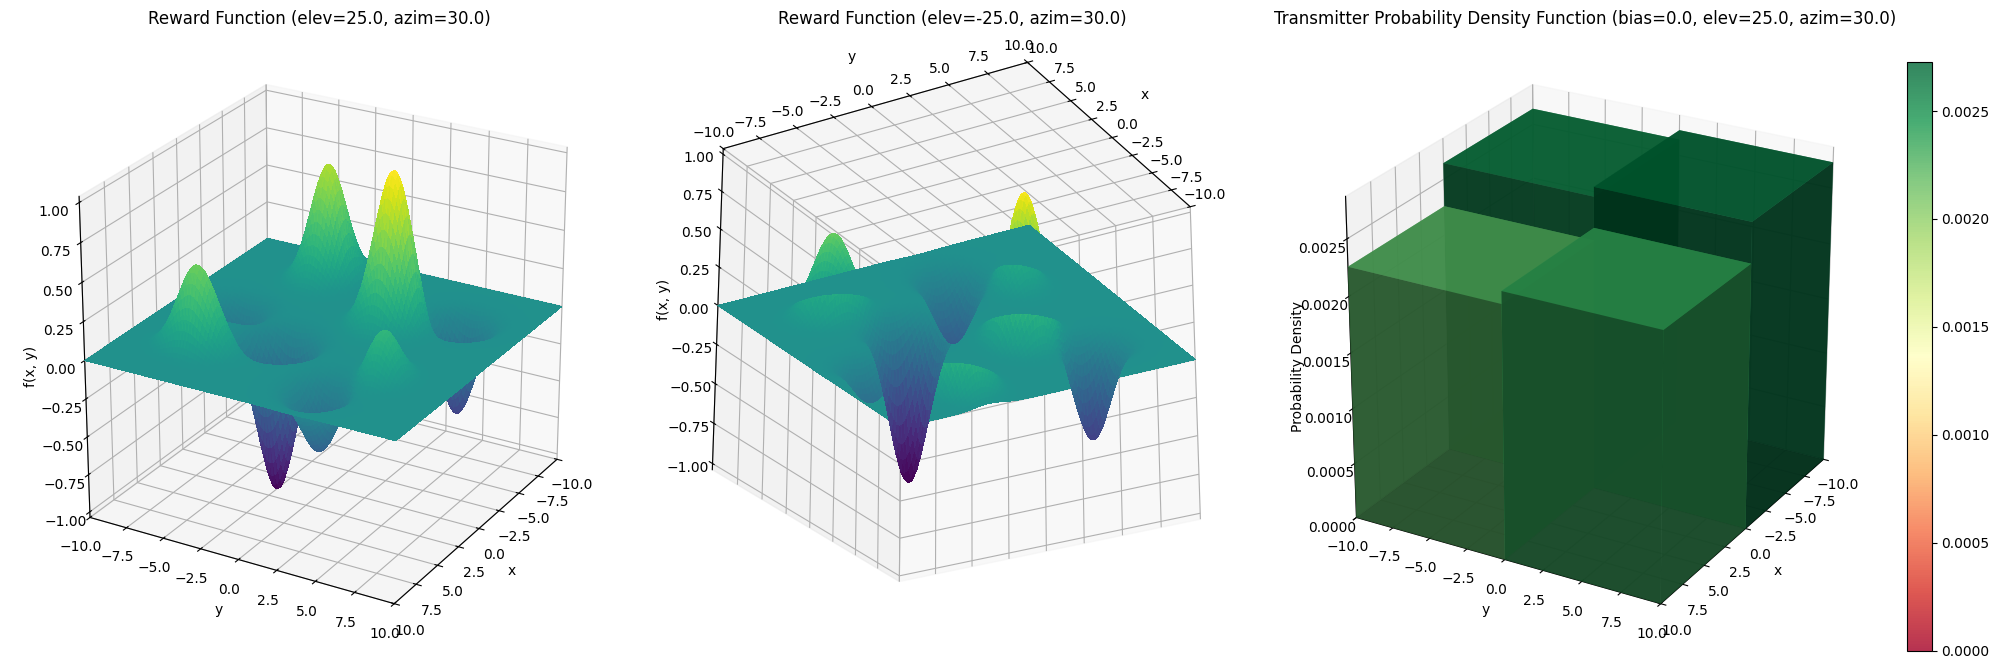

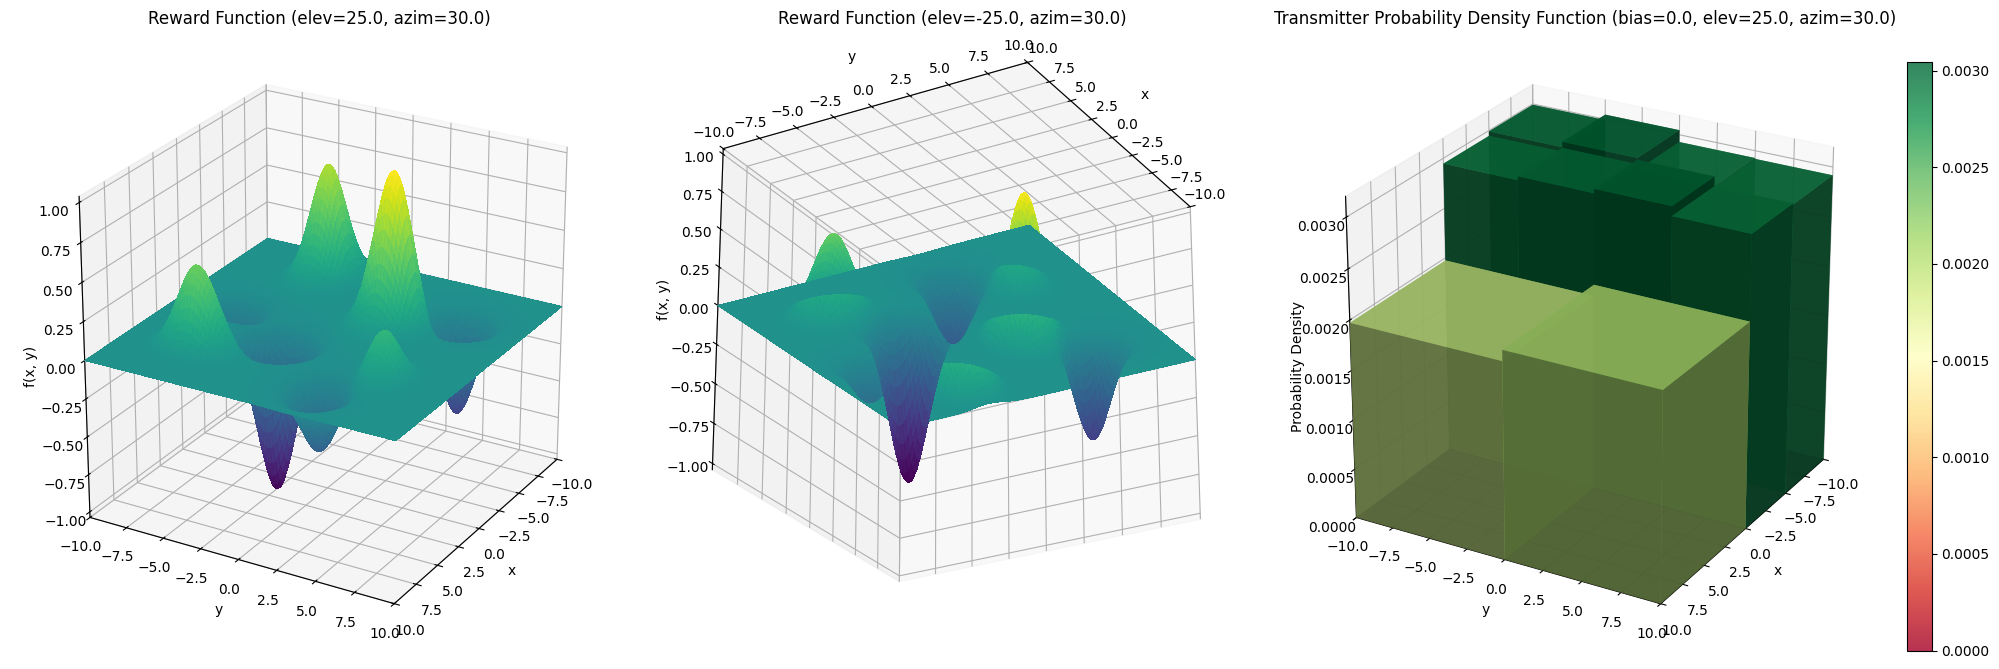

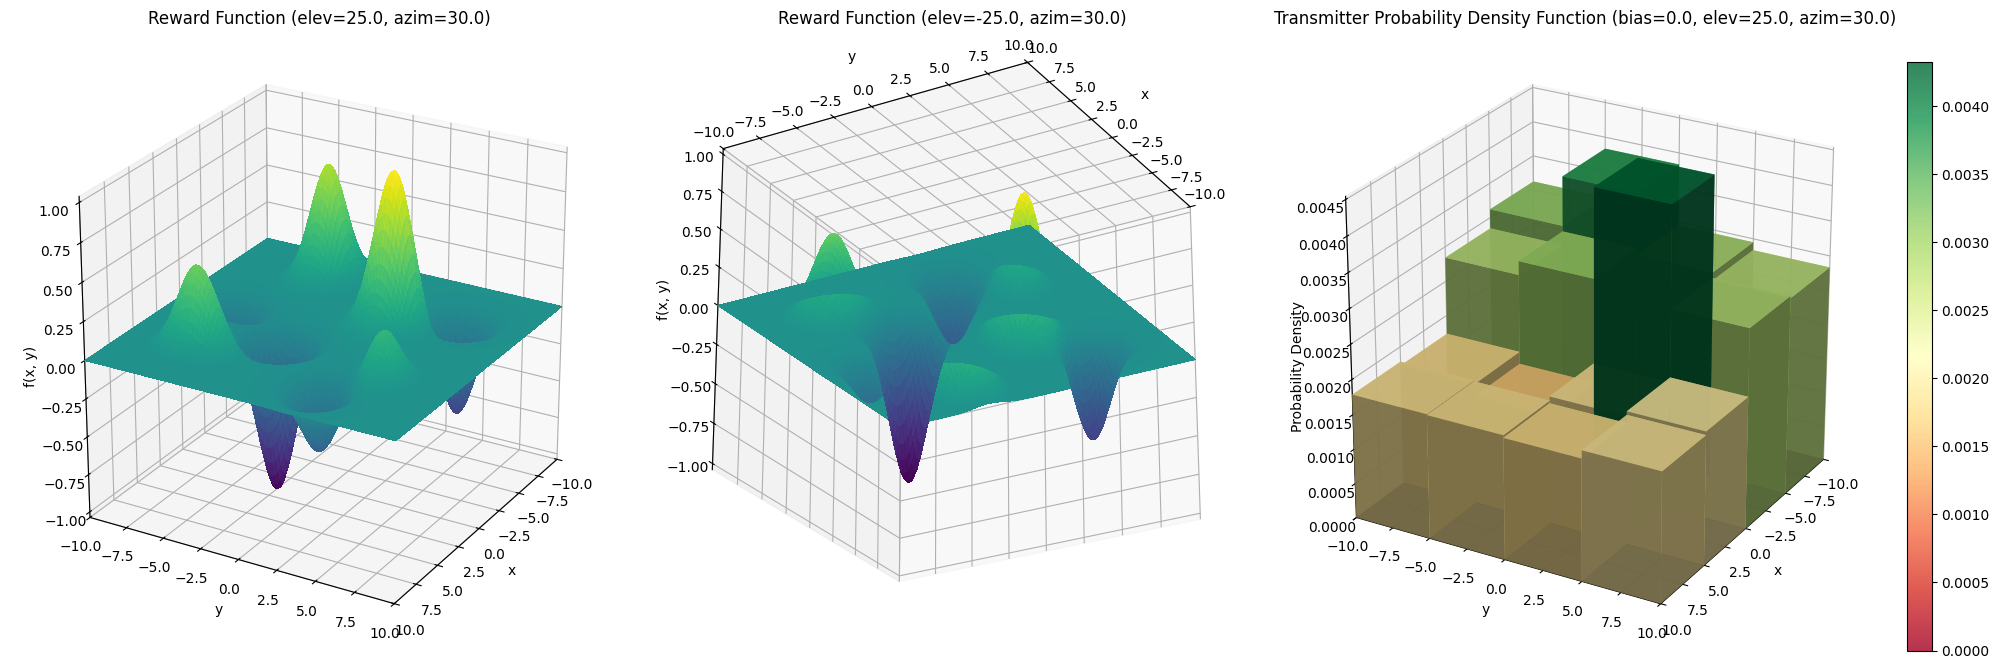

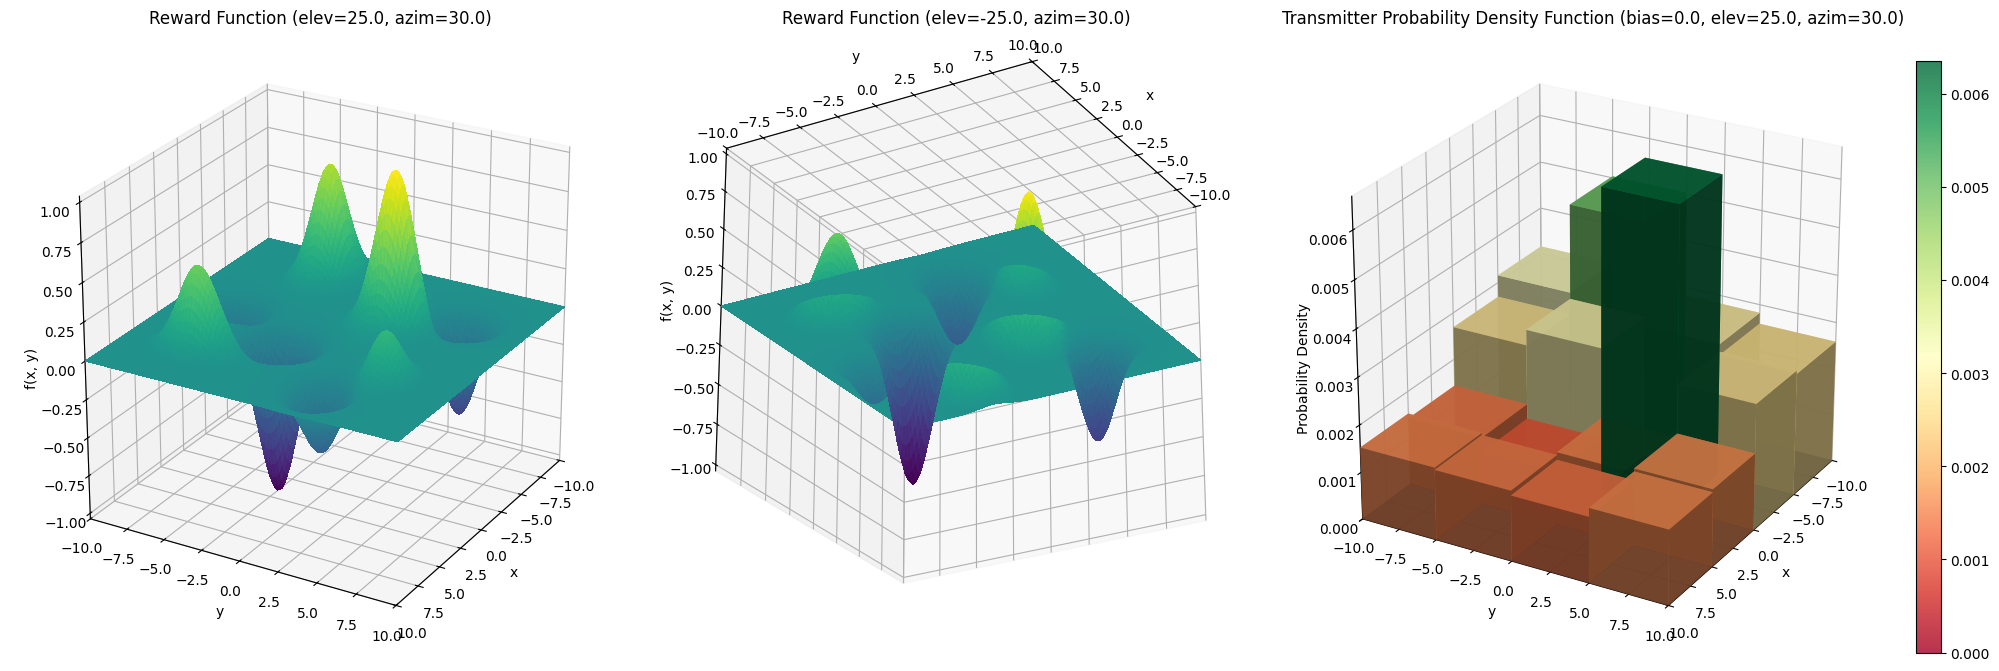

In [9]:
# set the transmitter plot steps
plot_steps = (
    {round(idx * (N_STEPS - 1) / (N_PLOTS - 1)) for idx in range(N_PLOTS)}
    if N_PLOTS > 1
    else {N_STEPS - 1}
)

# run simulation
for step in range(N_STEPS):
    print(f"Step {step + 1}/{N_STEPS}", end="\r")
    tsample = transmitter.forward(bias=0.0)
    reward = reward_function(tsample.coordinates[0], tsample.coordinates[1])
    transmitter.backward(tsample, reward)
    # plot the transmitter
    if step in plot_steps:
        fig, ax = plt.subplots(
            ncols=3, figsize=(20, 7), subplot_kw={"projection": "3d"}
        )
        plot_function(ax[0], reward_function, elev=25.0)
        plot_function(ax[1], reward_function, elev=-25.0)
        plot_transmitter(ax[2], transmitter, bias=0.0, elev=25.0)
        # adjust the aspect ratio of each plot
        for axis in ax:
            axis.set_box_aspect((1, 1, 1), zoom=0.95)
        fig.tight_layout()
        plt.show()

### Learning Animation

## Biased Sampling

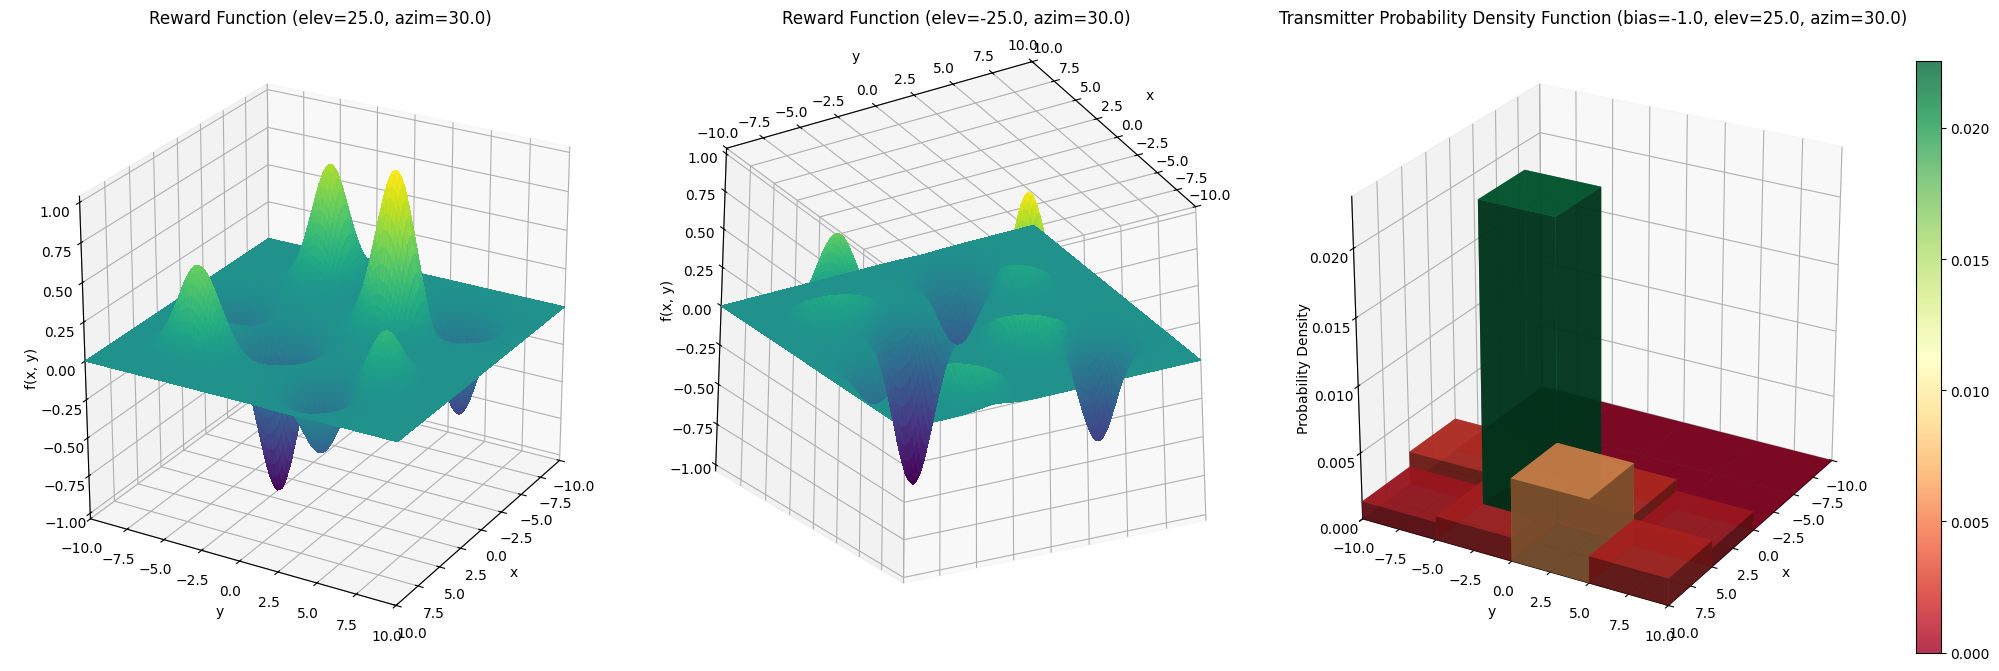

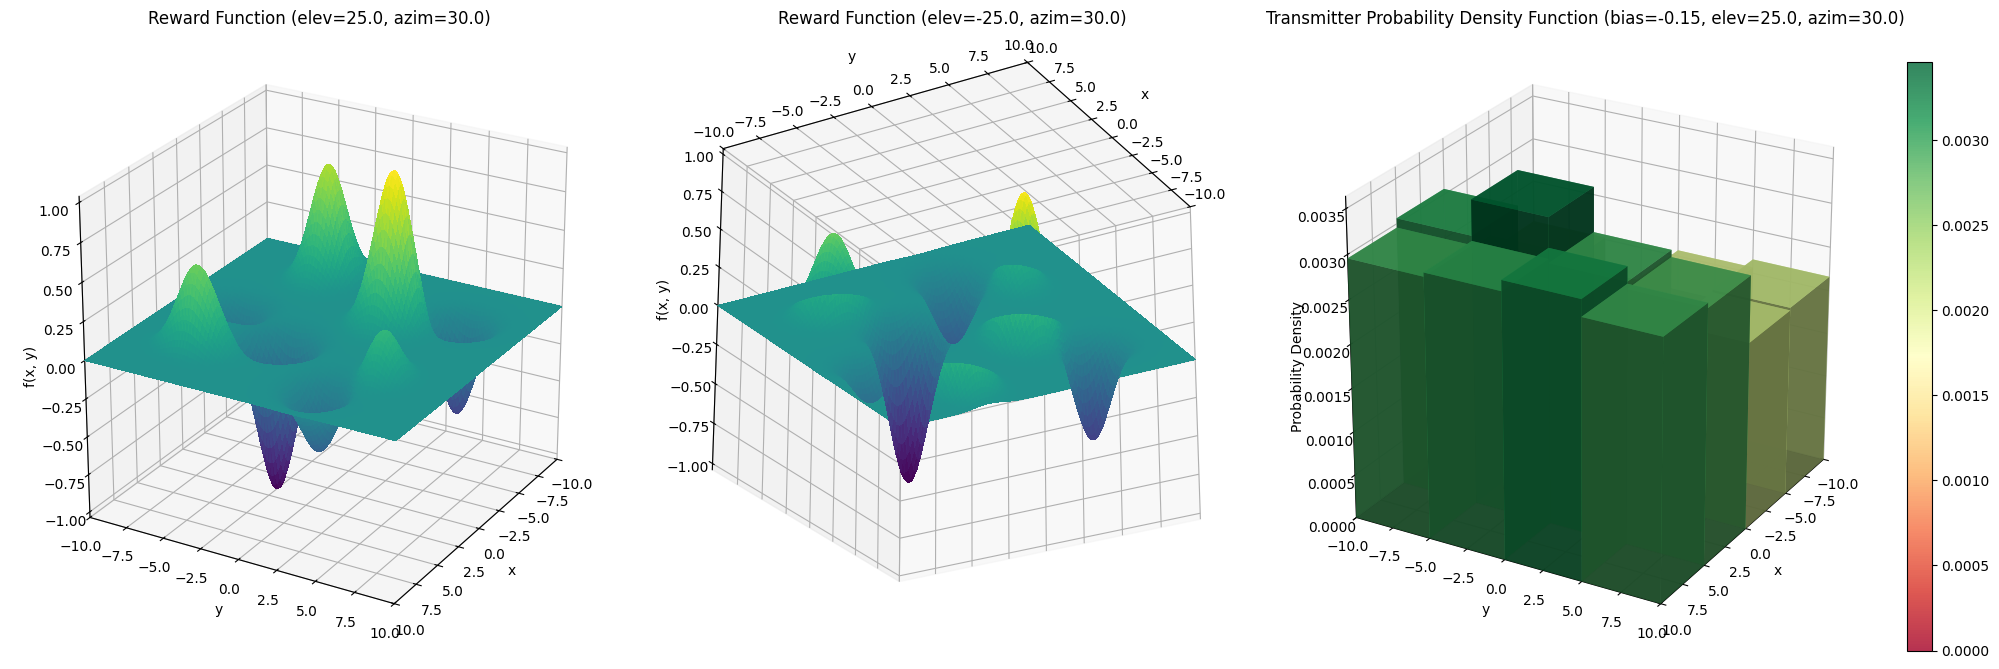

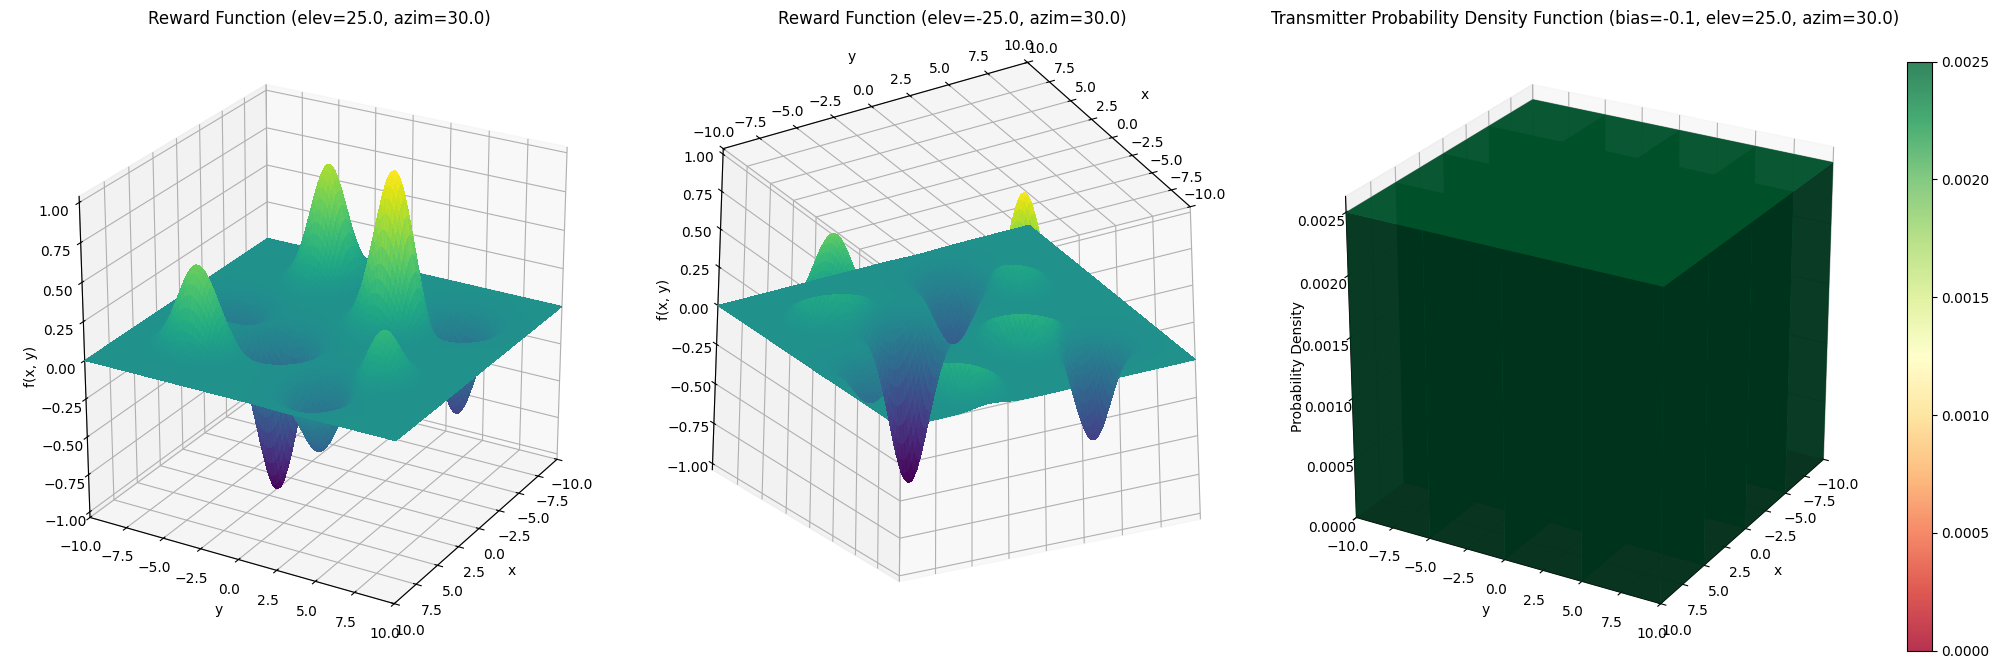

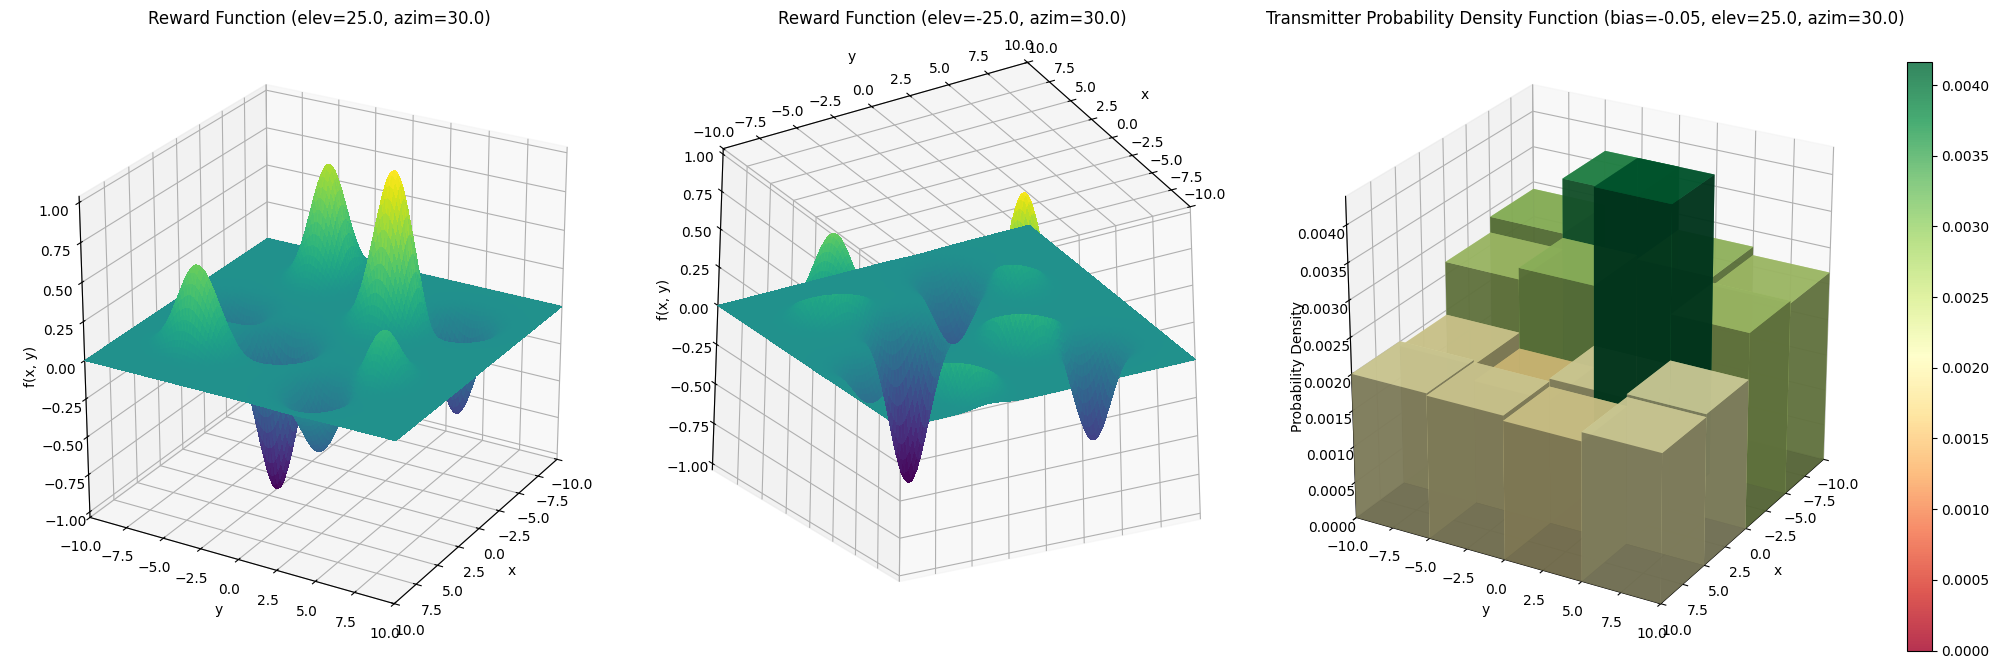

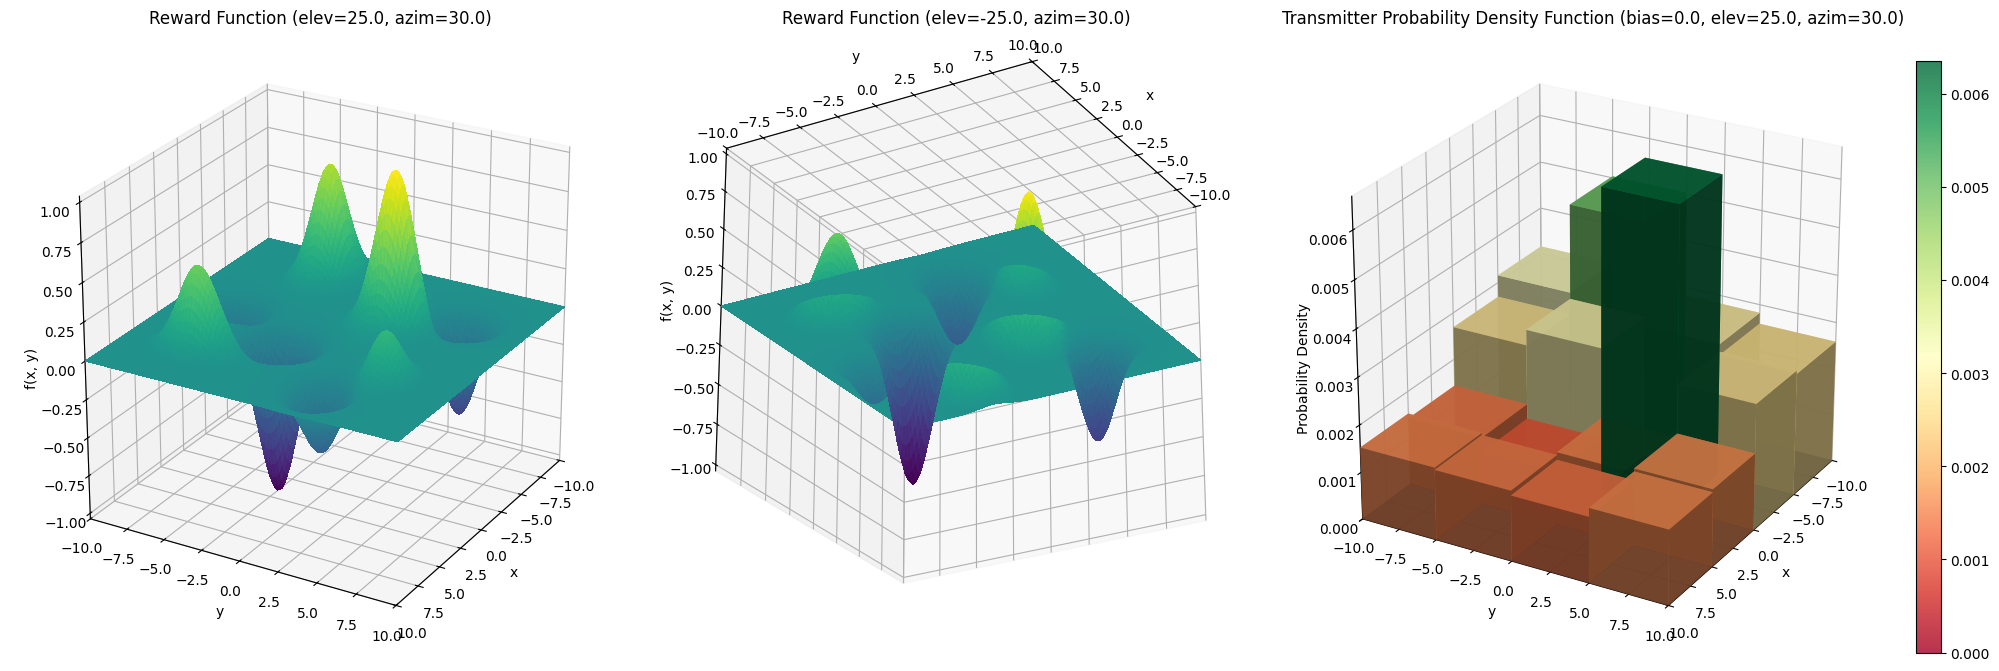

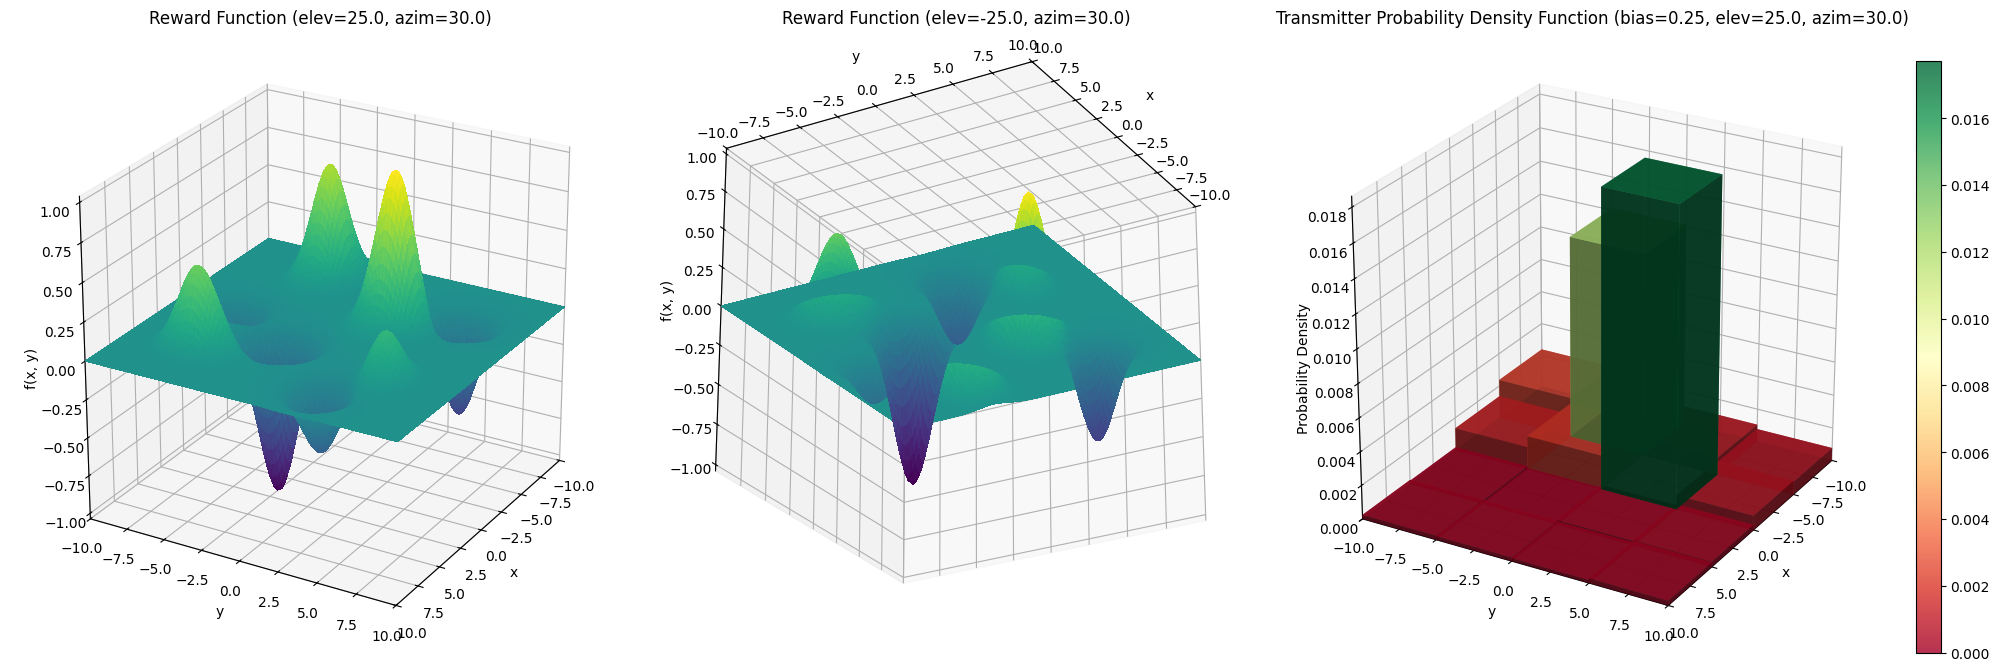

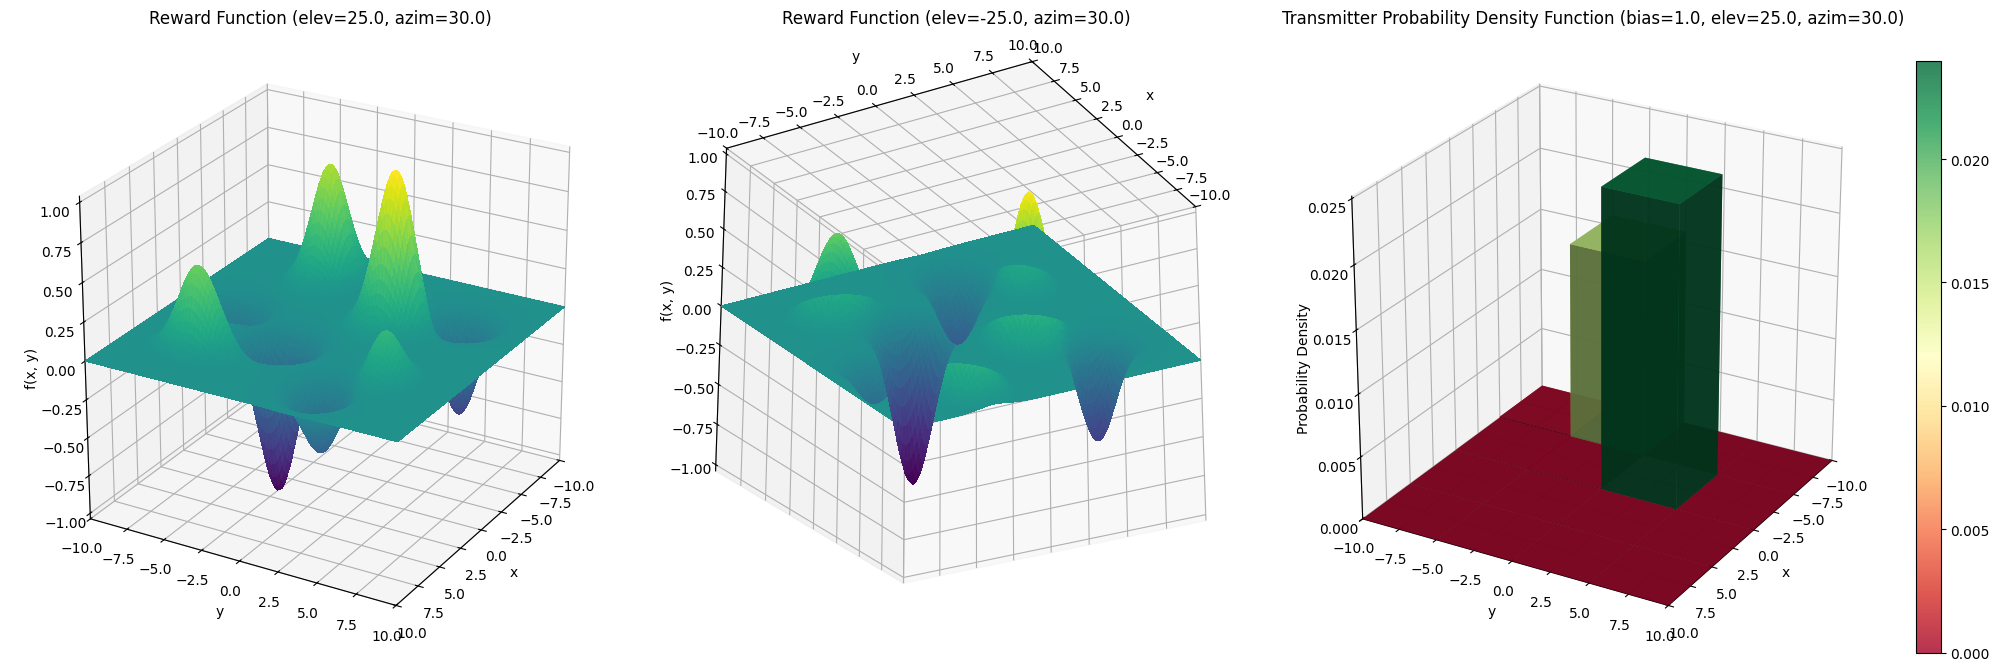

In [10]:
# define the list of biases to evaluate
biases = [-1.0, -0.15, -0.1, -0.05, 0.0, 0.25, 1.0]

# plot the transmitter for each bias
for bias in biases:
    fig, ax = plt.subplots(ncols=3, figsize=(20, 7), subplot_kw={"projection": "3d"})
    plot_function(ax[0], reward_function, elev=25.0)
    plot_function(ax[1], reward_function, elev=-25.0)
    plot_transmitter(ax[2], transmitter, bias, elev=25.0)
    # adjust the aspect ratio of each plot
    for axis in ax:
        axis.set_box_aspect((1, 1, 1), zoom=0.95)
    fig.tight_layout()
    plt.show()

### Bias Animation

## Conclusions